In [67]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

breaking the lme:

- high sc (e.g. 830)
- low number of patients (e.g. N_p = 10)

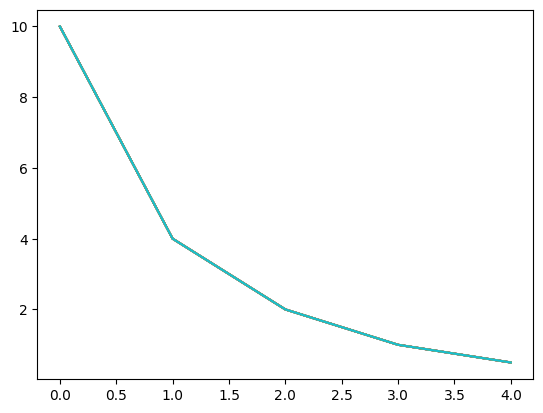

In [68]:
N_p = 10 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

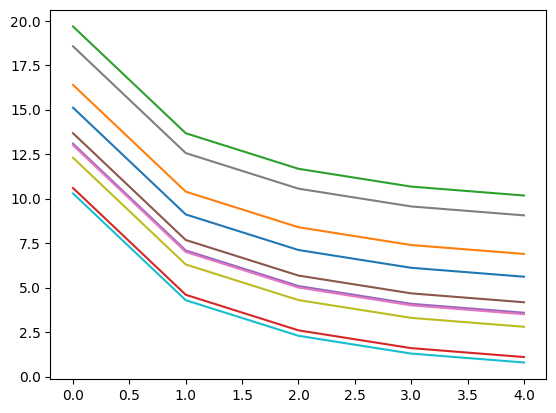

In [69]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

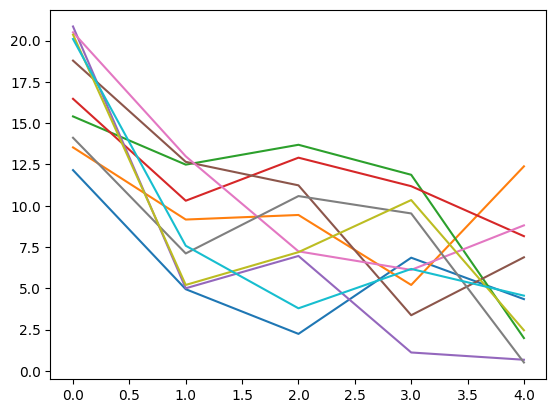

In [70]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [71]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:               MixedLM   Dependent Variable:   y       
No. Observations:    50        Method:               REML    
No. Groups:          10        Scale:                0.0000  
Min. group size:     5         Log-Likelihood:       311.1001
Max. group size:     5         Converged:            Yes     
Mean group size:     5.0                                     
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   14.267     0.446       32.005 0.000 13.394 15.141
Week[T.T1]  -6.000     0.000  -699934.805 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000  -933246.407 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -1049902.208 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -1108230.109 0.000 -9.500 -9.500
Patient Var  1.987 24435.732                                 
=============================================================

"""

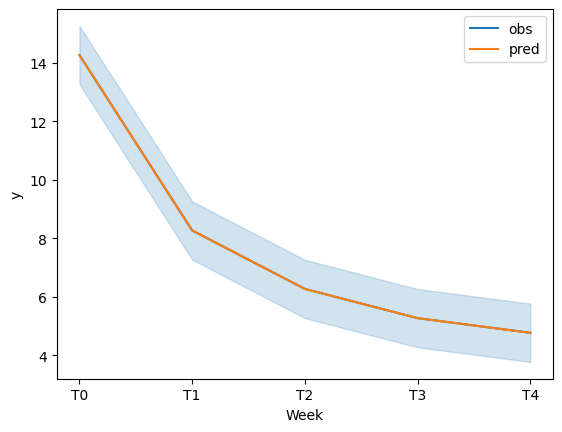

In [72]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [73]:
kill = np.random.randint(low=0, high=50, size=20)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM   Dependent Variable:   y       
No. Observations:   34        Method:               REML    
No. Groups:         10        Scale:                0.0000  
Min. group size:    1         Log-Likelihood:       155.0574
Max. group size:    5         Converged:            Yes     
Mean group size:    3.4                                     
------------------------------------------------------------
            Coef.   Std.Err.      z      P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept   14.267     0.555      25.693 0.000 13.179 15.356
Week[T.T1]  -6.000     0.000 -338558.107 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -551829.805 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -545303.790 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -637094.888 0.000 -9.500 -9.500
Patient Var  3.084 37097.448                                
============================================================

"""

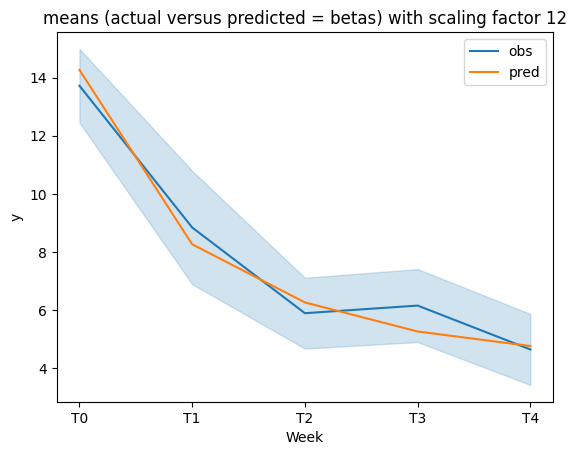

In [74]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()

# bi + b0 = mean(timepoint i) for i != 0
b[1:] += b[0] 
sem[1:] += sem[0]

sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()

## Multiplicative differences

Additive differences between subjs: should make sense to use the intercept (fitted lines will be additively different by subj_intercept (re) value).

Multiplicative:

In [75]:
df_mult = pd.DataFrame(data=y_mult, columns=[f'T{i}' for i in range(N_t)])
df_mult['Patient'] = np.arange(N_p) + 100
df_mult = pd.melt(df_mult, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
========================================================
Model:             MixedLM Dependent Variable: y        
No. Observations:  50      Method:             REML     
No. Groups:        10      Scale:              11.2504  
Min. group size:   5       Log-Likelihood:     -126.1761
Max. group size:   5       Converged:          Yes      
Mean group size:   5.0                                  
--------------------------------------------------------
             Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------
Intercept    17.225    1.122 15.348 0.000  15.026 19.425
Week[T.T1]   -8.482    1.500 -5.655 0.000 -11.422 -5.542
Week[T.T2]   -8.699    1.500 -5.799 0.000 -11.639 -5.759
Week[T.T3]  -10.050    1.500 -6.700 0.000 -12.990 -7.110
Week[T.T4]  -12.150    1.500 -8.100 0.000 -15.090 -9.210
Patient Var   1.345    0.565                            
========================================================

"""

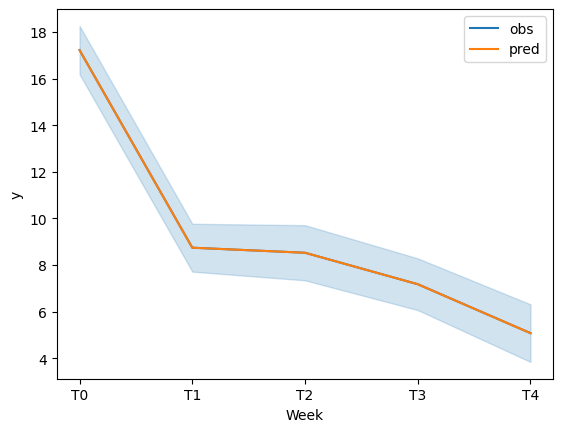

In [76]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [77]:
# same values killed as with the additive model
df_mult_kill = df_mult.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_mult_kill, groups='Patient').fit()

model.summary()


/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/UWO/mporwal2/Docume

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:             MixedLM  Dependent Variable:  y       
No. Observations:  34       Method:              REML    
No. Groups:        10       Scale:               9.4200  
Min. group size:   1        Log-Likelihood:      -78.5756
Max. group size:   5        Converged:           No      
Mean group size:   3.4                                   
---------------------------------------------------------
             Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept    18.704    1.326 14.104 0.000  16.105  21.303
Week[T.T1]  -10.225    1.895 -5.397 0.000 -13.938  -6.512
Week[T.T2]   -9.513    1.684 -5.648 0.000 -12.814  -6.212
Week[T.T3]  -11.998    1.827 -6.566 0.000 -15.579  -8.416
Week[T.T4]  -14.002    1.678 -8.342 0.000 -17.291 -10.712
Patient Var   0.101    0.604                             
=========================================================

"""

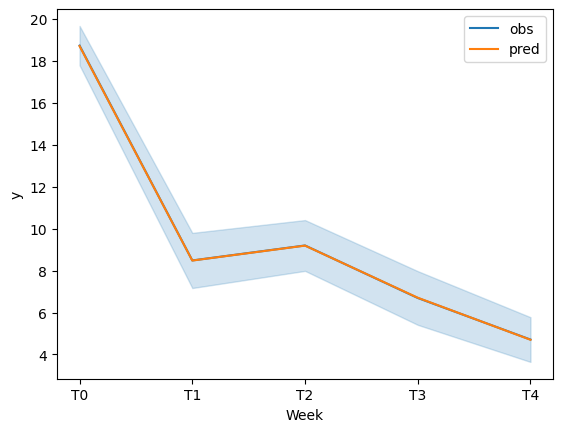

In [78]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult_kill, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)